In [1]:
%reset -f
import json


with open("../payload.json", "r") as f:
    scenario = json.load(f)

# reset initial conditions
# scenario["state_vessel_location"] = [0, 0]
# scenario["state_vessel_currentStorage"] = [2, 0]

from gspn4py import TimedPetriNet, OffshoreSimulator
from gspn4py.offshoreplan.offshore_utils import date_to_weather_index

import pm4py
from pm4py import Marking
from gspn4py.utils import import_pndf_from_json
from pprint import pprint


pndf = import_pndf_from_json(json_file_path="../models/offshore_models/full_cyclic_model.json")
pn = TimedPetriNet()
r = pn.build_from_pndf(pndf_json=pndf)
# pm4py.view_petri_net(pn, pn.initial_marking, pn.final_marking)


timed_simulator = OffshoreSimulator(timed_petri_net=pn, properties=scenario)

# timed_simulator.initialize()


# print(timed_simulator.net.get_obj_by_name(obj_name="P_BP"))


# timed_simulator.run_installation_cycle()
# sim_results = timed_simulator.calc_opt_install_cycle_single_vessel_single()
sim_results = timed_simulator.calc_opt_schedule_single_vessel_to_horizon()
# pm4py.view_petri_net(timed_simulator.net, timed_simulator.net.get_current_marking_obj(), timed_simulator.net.final_marking)
print('\n\n\n***********************')
pprint(sim_results)

# pprint()
# print(timed_simulator.net.get_list_of_priorities())
# sim_results = timed_simulator.calc_opt_schdule_immediate_from_current()
# pprint(sim_results)


Vessel is offshore.


***** Terminating simulation - Termination Model 1 ******
*******Terminate after t_SB*******
******** Installation Cycle finished. **********


Vessel is onshore.


***** Terminating simulation - Termination Model 1 ******
*******Terminate after t_SB*******
******** Installation Cycle finished. **********


All OWTs are built. No need to run installation cycle.
All OWTs are built. No need to run installation cycle.
All OWTs are built. No need to run installation cycle.
All OWTs are built. No need to run installation cycle.
All OWTs are built. No need to run installation cycle.
All OWTs are built. No need to run installation cycle.
All OWTs are built. No need to run installation cycle.



***********************
{'end_at': 352,
 'owts_finished': 1,
 'plan': [('SailingBack', 4, 28, 1387, 1418),
          ('LoadingOWT', 12, 0, 1419, 1430),
          ('SailingForth', 4, 0, 1431, 1434),
          ('Reposition', 2, 0, 1435, 1436),
          ('JackUp', 2, 0, 1437, 1438),

In [2]:
def convert_sim_results_to_response(sim_results:dict):
    
    ops = sim_results["plan"]
    
    pattern = ["Reposition", "JackUp", "Construction", "JackDown"]
    merged = []
    i = 0
    
    while i < len(ops):
        # check if the next operations match the pattern
        # op = (op_name, op_duration, op_delay, op_start, op_end)
        if (i + 3 < len(ops) and [ops[i][0], ops[i+1][0], ops[i+2][0], ops[i+3][0]] == pattern) :
                
                op_name = 'Install'
                op_duration = ops[i][1] + ops[i+1][1] + ops[i+2][1] + ops[i+3][1]
                op_delay = ops[i][2] + ops[i+1][2] + ops[i+2][2] + ops[i+3][2]
                op_start = ops[i][3] # start of "Reposition"
                op_end = ops[i+3][4] # end of "JackDown"
                
                merged.append((op_name, op_duration, op_delay, op_start, op_end))
                i += 4  # Skip the merged ones
        elif ops[i][0] == "LoadingOWT":
            n = int(ops[i][1]/12)
            for j in range(n):
                if j == n-1:
                    temp = (ops[i][0], 12, ops[i][2], ops[i][3]+12*j, ops[i][3]+12*(j+1)+ops[i][2]-1)
                else:
                    temp = (ops[i][0], 12, 0, ops[i][3]+12*j, ops[i][3]+12*(j+1)-1)
                    
                merged.append(temp)
            i += 1
        else:
            merged.append(ops[i])
            i += 1
    
    pprint(merged)
    
    mapping_operationId = {
        "LoadingOWT": 3, # load
        "SailingForth": 2, # to_site
        "SailingBack": 1, # to_port
        "Install" : 0,
        # "Construction": 0, # install
        # "JackUp": 0, # install
        # "JackDown": 0, # install
        # "Reposition": 0 # install
    }
    operationsId = []
    operationsStart = []
    operationsEnd = []
    
    
    for op in merged:
        operationsId.append(mapping_operationId[op[0]])
        operationsStart.append(op[3])
        operationsEnd.append(op[4])
    
    results = {
                "planned_operationsId": [[-1], operationsId],
                "planned_operationsStart": [[-1], operationsStart],
                "planned_operationsEnd": [[-1], operationsEnd],
                "planned_restockOperations": [-1]
            }
    return  results


formatted_results = convert_sim_results_to_response(sim_results)
print('\n\n\n***********************')
pprint(formatted_results)

[('SailingBack', 4, 28, 1387, 1418),
 ('LoadingOWT', 12, 0, 1419, 1430),
 ('SailingForth', 4, 0, 1431, 1434),
 ('Install', 20, 0, 1435, 1454),
 ('SailingBack', 4, 0, 1455, 1458)]



***********************
{'planned_operationsEnd': [[-1], [1418, 1430, 1434, 1454, 1458]],
 'planned_operationsId': [[-1], [1, 3, 2, 0, 1]],
 'planned_operationsStart': [[-1], [1387, 1419, 1431, 1435, 1455]],
 'planned_restockOperations': [-1]}


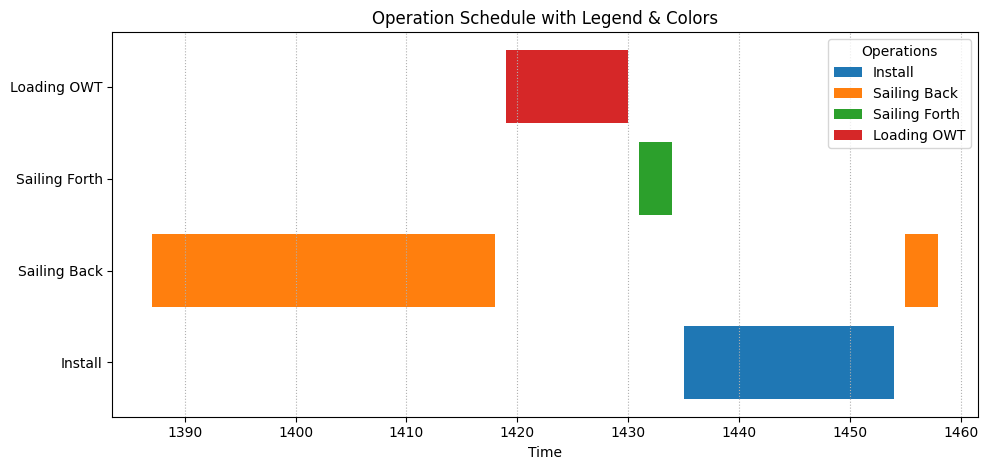

In [3]:
# Update: color by operation and add a legend using the provided mapping.
# We'll extend `plot_schedule_from_planned` to accept `mapping_operationId`
# and show distinct colors + legend entries for each op.
#
# Demo uses the user's sample plus the mapping.

import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, date2num
from matplotlib.patches import Patch
import numpy as np
from datetime import datetime
from typing import Iterable, List, Tuple, Dict, Union, Optional

def _is_sentinel_empty(lst):
    return isinstance(lst, list) and len(lst) == 1 and lst[0] == -1

def _to_num(x):
    if not isinstance(x, Iterable) or isinstance(x, (str, bytes)):
        x = [x]
    x = list(x)
    if not x:
        return np.array([]), False
    sample = x[0]
    is_dt = isinstance(sample, (datetime, np.datetime64))
    if is_dt:
        x_dt = []
        for v in x:
            if isinstance(v, np.datetime64):
                ts = (v - np.datetime64('1970-01-01T00:00:00Z')) / np.timedelta64(1, 's')
                x_dt.append(datetime.utcfromtimestamp(float(ts)))
            else:
                x_dt.append(v)
        return np.array([date2num(v) for v in x_dt]), True
    else:
        return np.asarray(x, dtype=float), False

def _flatten_planned(planned: Dict) -> Tuple[List[Union[float, datetime]],
                                             List[Union[float, datetime]],
                                             List[int]]:
    starts_ll = planned.get("planned_operationsStart", [])
    ends_ll   = planned.get("planned_operationsEnd", [])
    ids_ll    = planned.get("planned_operationsId", [])
    if not (len(starts_ll) == len(ends_ll) == len(ids_ll)):
        raise ValueError("planned_operationsStart/End/Id must have the same outer length.")
    starts, ends, ids = [], [], []
    for s_list, e_list, i_list in zip(starts_ll, ends_ll, ids_ll):
        if _is_sentinel_empty(s_list) and _is_sentinel_empty(e_list) and _is_sentinel_empty(i_list):
            continue
        if not (len(s_list) == len(e_list) == len(i_list)):
            raise ValueError("Mismatched lengths inside planned_* sublists.")
        starts.extend(s_list)
        ends.extend(e_list)
        ids.extend(i_list)
    return starts, ends, ids

def plot_schedule_from_planned(
    planned: Dict,
    mapping_operationId: Optional[Dict[str, int]] = None,
    title: str = "Operation Schedule",
    xlabel: str = "Time",
    show_restock: bool = True,
):
    # Flatten
    op_start, op_stop, op_id = _flatten_planned(planned)
    if not op_start:
        raise ValueError("No intervals to plot (all lists were [-1]).")
    
    # Map op IDs -> human-readable names
    unique_ids = sorted(set(op_id))
    id_to_name: Dict[int, str] = {i: f"Op {i}" for i in unique_ids}
    if mapping_operationId:
        # invert mapping: id -> name (preserve insertion order of mapping keys)
        for name, i in mapping_operationId.items():
            if i in unique_ids:
                id_to_name[i] = name
    
    # Colors: choose distinct colors from the default cycle and assign per ID
    cycle_colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    id_to_color: Dict[int, Optional[str]] = {}
    for idx, i in enumerate(unique_ids):
        if cycle_colors:
            id_to_color[i] = cycle_colors[idx % len(cycle_colors)]
        else:
            id_to_color[i] = None  # let matplotlib decide
    
    # Group intervals per ID
    intervals_by_id: Dict[int, List[Tuple[Union[float, datetime], Union[float, datetime]]]] = {
        i: [] for i in unique_ids
    }
    for s, e, i in zip(op_start, op_stop, op_id):
        if e < s:
            raise ValueError("Found an interval with stop < start.")
        intervals_by_id[i].append((s, e))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ids_sorted = unique_ids  # keep ascending order
    y_positions = np.arange(len(ids_sorted))
    height = 0.8
    is_datetime = False
    
    for row, i in enumerate(ids_sorted):
        intervals = intervals_by_id[i]
        if not intervals:
            continue
        starts = [s for s, _ in intervals]
        stops  = [e for _, e in intervals]
        starts_num, dt_a = _to_num(starts)
        stops_num, dt_b  = _to_num(stops)
        is_datetime = is_datetime or dt_a or dt_b
        spans = [(float(s), float(e - s)) for s, e in zip(starts_num, stops_num)]
        ax.broken_barh(spans, (y_positions[row] - height/2, height),
                       facecolors=id_to_color[i])
    
    # Restock markers
    if show_restock and "planned_restockOperations" in planned:
        restock = planned["planned_restockOperations"]
        if not _is_sentinel_empty(restock):
            if restock and isinstance(restock[0], list):
                restock_times = [t for sub in restock if not _is_sentinel_empty(sub) for t in sub]
            else:
                restock_times = restock
            times_num, dt_r = _to_num(restock_times)
            is_datetime = is_datetime or dt_r
            for t in times_num:
                ax.axvline(float(t), linestyle="--", linewidth=1)
    
    # Axes labels and formatting
    ax.set_yticks(y_positions, [id_to_name[i] for i in ids_sorted])
    if is_datetime:
        locator = AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(ConciseDateFormatter(locator))
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, axis='x', linestyle=':', linewidth=0.8)
    
    # Legend
    legend_patches = [Patch(facecolor=id_to_color[i] if id_to_color[i] else 'C0',
                            label=id_to_name[i]) for i in ids_sorted]
    ax.legend(handles=legend_patches, title="Operations", loc="upper right")
    
    fig.tight_layout()
    plt.show()

# ---------------- DEMO with the user's sample + mapping ----------------
# sample = {
#     'planned_operationsEnd':   [[-1], [12,  24, 36, 48, 52, 72, 92, 112, 132, 136, 12, 136, 156, 160]], 
#     'planned_operationsId':    [[-1], [3, 3, 3, 3, 2, 0, 0, 0, 0, 1, 3, 2, 0, 1]],
#     'planned_operationsStart': [[-1], [0,  12,  24, 36, 48, 52, 72, 92, 112, 132, 0, 132, 136, 156]], 
#     'planned_restockOperations': [-1]
# }

mapping_operationId = {
    "Loading OWT": 3,   # load
    "Sailing Forth": 2, # to_site
    "Sailing Back": 1,  # to_port
    "Install": 0,
}

plot_schedule_from_planned(formatted_results, mapping_operationId=mapping_operationId,
                           title="Operation Schedule with Legend & Colors")


In [4]:
print(formatted_results)

{'planned_operationsId': [[-1], [1, 3, 2, 0, 1]], 'planned_operationsStart': [[-1], [1387, 1419, 1431, 1435, 1455]], 'planned_operationsEnd': [[-1], [1418, 1430, 1434, 1454, 1458]], 'planned_restockOperations': [-1]}


In [5]:
for i in range(1):
    print(i)

0


In [6]:
tok = timed_simulator.net.get_tokens_by_property(property_name="type", property_value="Vessel")[0]
print(tok.properties)
print(tok.consumed)

{'type': 'Vessel', 'vessel_idx': 0, 'capacity': 4, 'current_storage': 0, 'num_to_do': 1}
[(60, 0), (67, 0), (64, 12), (65, 16), (70, 18), (69, 20), (71, 34), (68, 36)]


In [7]:
for t in timed_simulator.net.transitions:
    print(t, t.transition_id)

(n:t_SF, l:SailingForth, d:4) 64
(n:t_JD0, l:JackDown, d:2) 66
(n:t_R, l:Reposition, d:2) 65
(n:t_Load, l:LoadingOWT, d:12) 67
(n:t_C, l:Construction, d:14) 69
(n:t_JD1, l:JackDown, d:2) 71
(n:t_SB, l:SailingBack, d:4) 68
(n:t_JU, l:JackUp, d:2) 70


In [8]:
timed_simulator.get_sim_results()

{'net_id': 8,
 'initial_marking': ['P_BP:16', 'P_C:0', 'P_IV:1', 'P_JD:0', 'P_JU:0', 'P_OWF:0', 'P_R:0', 'P_SB:0', 'P_SF:0'],
 'final_marking': ['P_BP:15', 'P_C:0', 'P_IV:1', 'P_JD:0', 'P_JU:0', 'P_OWF:1', 'P_R:0', 'P_SB:0', 'P_SF:0'],
 'firing_sequence': [{'SailingForth': [12]},
  {'JackDown': []},
  {'Reposition': [16]},
  {'LoadingOWT': [0]},
  {'Construction': [20]},
  {'JackDown': [34]},
  {'SailingBack': [36]},
  {'JackUp': [18]}],
 'end_at': 40}

In [9]:
timed_simulator.net.get_current_marking_obj()

['P_BP:15', 'P_C:0', 'P_IV:1', 'P_JD:0', 'P_JU:0', 'P_OWF:1', 'P_R:0', 'P_SB:0', 'P_SF:0']

In [10]:

for t in timed_simulator.net.get_all_tokens():
    print(t.properties)

{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'OWT'}
{'type': 'Vessel', 'vessel_idx': 0, 'capacity': 4, 'current_storage': 0, 'num_to_do': 1}
{'type': 'OWT'}


In [11]:
for p in timed_simulator.net.places:
    if p.num_of_tokens > 0:
        print(p.tokens)

{19, 21, 18, 20, 22, 23, 24, 25, 26, 29, 30, 28, 31, 27, 32}
{33}
{17}


In [12]:
from pprint import pprint
# pprint(timed_simulator.net.arcs)
print(timed_simulator.net.get_arc(source_name="P_BP", target_name="t_Load"))


P_BP->(n:t_Load, l:LoadingOWT, d:12)


In [13]:
for a in timed_simulator.net.arcs:
    print(a.source.name)
    print(a.target.name)

t_Load
P_SF
t_R
P_JU
P_R
t_R
t_SF
P_R
P_JU
t_JU
t_JU
P_C
P_C
t_C
t_C
P_OWF
t_C
P_JD
P_SF
t_SF
P_SB
t_SB
P_IV
t_Load
t_JD0
P_R
t_SB
P_IV
P_JD
t_JD1
P_JD
t_JD0
t_JD1
P_SB
P_BP
t_Load


In [14]:
# timed_simulator.run()
# pprint(timed_simulator.get_sim_results())

In [15]:
{'A', 'B', 'C'}.pop()

'C'

In [16]:
(1, 2, 3)[2]

3

In [17]:
d = {'a': 1}

print(d.get('b'))

None


In [18]:
vessel_capacity = 4
vessel_storage = 4

if vessel_capacity - vessel_storage > 0:
    max_to_load = vessel_capacity - vessel_storage
    combinations = [(x, y) for x in range(1, max_to_load+1) for y in range(1, x + vessel_storage+1)]
else:
    combinations = [(0, y) for y in range(1, vessel_storage + 1)]
    
print(combinations)

[(0, 1), (0, 2), (0, 3), (0, 4)]


In [19]:
for x, y in combinations:
    print(f"Load {x} components, store {y} in vessel storage.")

Load 0 components, store 1 in vessel storage.
Load 0 components, store 2 in vessel storage.
Load 0 components, store 3 in vessel storage.
Load 0 components, store 4 in vessel storage.


In [20]:
a = [(1, 1), (2, 1), (3, 1), (4, 1), (5, 1)]

for i in a:
    print(i[0])
    if i[0] > 3:
        a.remove(i)
        
print(a)

1
2
3
4
[(1, 1), (2, 1), (3, 1), (5, 1)]
